In [ ]:
!torchrun --standalone --nproc_per_node=4 ../src/social_media_overlay/ddp_train_latent.py

[2026-03-19 12:16:04,717] torch.distributed.run: [WARNING] master_addr is only used for static rdzv_backend and when rdzv_endpoint is not specified.
[2026-03-19 12:16:04,717] torch.distributed.run: [WARNING] 
[2026-03-19 12:16:04,717] torch.distributed.run: [WARNING] *****************************************
[2026-03-19 12:16:04,717] torch.distributed.run: [WARNING] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
[2026-03-19 12:16:04,717] torch.distributed.run: [WARNING] *****************************************
name: imagenet2imagenet
type: imaginaire.datasets.unpaired_images
num_workers: 8
input_types:
    images_a:
        ext: jpg
        num_channels: 3
        normalize: True
    images_b:
        ext: jpg
        num_channels: 3
        normalize: True
train:
    roots: ['/data/cgebhard/imagenet2imagenet/train']
    bat

Loaded 501 loss values


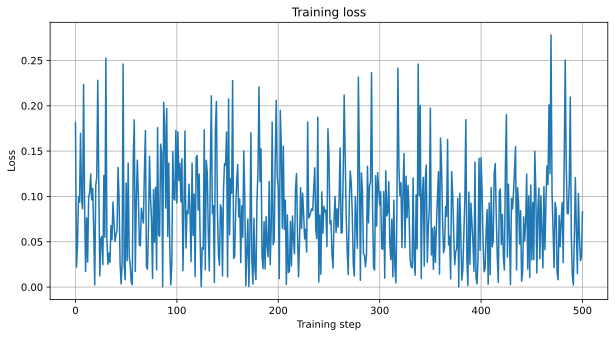

In [ ]:
import torch
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

saved_path="../data/models/checkpoints-test/test-0-500.pt"
checkpoint = torch.load(saved_path)

loss_history = checkpoint["loss_history"]

print(f"Loaded {len(loss_history)} loss values")

plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
#plt.savefig("../data/models/checkpoints-ganalyze-256/checkpoints-ganalyze-256-b4-ddp-final.loss.svg", format="svg")
plt.show()